In [2]:
import torch
import optuna
from optuna.samplers import NSGAIISampler
import numpy as np
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
from torch.distributions import Normal
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import random
# --------------------------------------------------
# 假设模型和标准化器的路径
DIR = "output_BayesianNN"
OUTPUT_PATH = "NSGA-2-TOPSIS"
MODEL_PATH = DIR + "/" + "models"
FEATURE_SCALER_PATH = DIR + "/" + "scaler/feature_scaler"
TARGET_SCALER_PATH = DIR + "/" + "scaler/target_scaler"
os.makedirs(OUTPUT_PATH, exist_ok=True)
SEED = 3047
DEVICE = torch.device("cpu")
VAR_NAMES = ['FA/C', 'w/b', 's/b', 'SP/B', 'Vf', 'If']
IF_VALUES = [0.202007361]  # PVA

e:\Anaconda3\Installment\envs\pytorch_cw\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 多 GPU 情况下
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # 关闭 CUDNN 的自动优化

set_seed(SEED)  # 设置默认随机种子为 42

In [4]:
class BayesianRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, output_size=1, dropout_p=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 2*hidden_size)
        self.output = nn.Linear(2*hidden_size, output_size*2)  # 输出均值和log方差
        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        output = self.output(x)
        
        # 将输出分成均值和log方差
        mean = output[:, :1]
        logvar = output[:, 1:]
        
        return mean, logvar

class BayesianNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size=32, output_size=1, dropout_p=0.1):

        super().__init__()
        self.model = BayesianRegressor(input_size, hidden_size, output_size, dropout_p)
        
    def forward(self, x):
        mean, logvar = self.model(x)
        return mean, logvar
    
    def predict_with_uncertainty(model, x, n_samples=100):
        # 数据不确定性 (eval模式)
        model.eval()
        mean, logvar = model(x)
        data_var = torch.exp(logvar).squeeze() 
        
        # 模型不确定性 (train模式)
        model.train()
        mc_samples = torch.stack([model(x)[0] for _ in range(n_samples)])
        model_var = mc_samples.var(dim=0).squeeze()  # 计算模型不确定性
        
        total_var = data_var + model_var
        return mean, total_var.sqrt(), data_var.sqrt(), model_var.sqrt()
    
    def nll(self, x, y):
        """计算负对数似然损失"""
        mean, logvar = self(x)
        inv_var = torch.exp(-logvar)
        loss = torch.sum(inv_var * (y - mean)**2 + logvar) / y.shape[0]
        return loss

# 数据集类（保持原样）
class Data(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.device = DEVICE

    def __len__(self):
        assert len(self.X) == len(self.y)
        return len(self.y)

    def __getitem__(self, i):
        return (
            torch.FloatTensor(self.X[i]).to(self.device),
            torch.FloatTensor(self.y[i]).to(self.device)
        )

In [5]:
# --------------------------------------------------
# 加载资源函数
def load_resources():
    device = torch.device('cpu')
    models = {
        'p_v': torch.load(os.path.join(MODEL_PATH, "p_v_best_model.pth")).to(device),
        'us2': torch.load(os.path.join(MODEL_PATH, "ux2_best_model.pth")).to(device)
    }
    scalers = {
        'feature': joblib.load(os.path.join(FEATURE_SCALER_PATH, "input_feature_scaler.pkl")),
        'p_v': joblib.load(os.path.join(TARGET_SCALER_PATH, "p_v_target_scaler.pkl")),
        'us2': joblib.load(os.path.join(TARGET_SCALER_PATH, "us2_target_scaler.pkl"))
    }
    return models, scalers

In [6]:
class ConcreteMultiObjectiveStudy:
    def __init__(self):
        self.models, self.scalers = load_resources()
        self.IF_VALUES = IF_VALUES
    def calculate_mass_percent(self, FA_C, w_b, s_b, SP_B, Vf, rho_f=1.3, B=1000):
        """计算各组分的质量百分数"""
        C = B / (1 + FA_C)
        FA = FA_C * C
        W = w_b * B
        S = s_b * B
        SP = SP_B * B
        
        densities = np.array([3.1, 2.5, 1.0, 2.65, 1.1])
        masses = np.array([C, FA, W, S, SP])
        V_total = sum(masses / densities)
        PV = Vf/100 * rho_f * V_total
        
        total_mass = C + FA + W + S + SP + PV
        return {
            'Cement': (C / total_mass),
            'Fly Ash': (FA / total_mass) ,
            'Water': (W / total_mass),
            'Sand': (S / total_mass),
            'Superplasticizer': (SP / total_mass),
            'PVA Fiber': (PV / total_mass) 
        }
    
    # $/t
    def calculate_cost(self, X):
        """计算成本（返回单个数值）"""
        costs = {
            'Cement': 49.1, 'Fly Ash': 23.1, 'Water': 0.4,
            'Sand': 196, 'Superplasticizer': 8960, 'PVA Fiber': 70000
        }
        FA_C, w_b, s_b, SP_B, Vf, If = X[0]
        percent = self.calculate_mass_percent(FA_C, w_b, s_b, SP_B, Vf)
        # 直接返回数值而不是数组
        return sum(percent[k] * costs[k] for k in percent)
    
    def predict(self, model, X, target_scaler):
        """生成带有不确定性的预测"""
        model.eval()
        with torch.no_grad():
            pred, std, _, _ = model.predict_with_uncertainty(torch.FloatTensor(X).to(DEVICE), n_samples=100)
            pred_scaled = target_scaler.inverse_transform(pred.cpu().numpy())
            std_scaled = std * target_scaler.data_range_[0]
        return pred_scaled, std_scaled
    
    def create_study(self, n_trials=200, population_size=100):
        # 目标函数
        def objective(trial):
            params = {
                'FA/C': trial.suggest_float('FA/C', 0, 4.0, step=0.1),
                'w/b': trial.suggest_float('w/b', 0.2, 0.4, step=0.01),
                's/b': trial.suggest_float('s/b', 0.3, 1.2, step=0.1),
                'SP/B': trial.suggest_float('SP/B', 0.01, 0.1, step=0.005),
                'Vf': trial.suggest_float('Vf', 0.5, 2, step=0.1),
                'If': trial.suggest_categorical('If', self.IF_VALUES)
            }
            
            X = np.array([[params['FA/C'], params['w/b'], params['s/b'], params['SP/B'], params['Vf'], params['If']]])
            X_scaled = self.scalers['feature'].transform(X)
            # 预测
            p_v_mean, p_v_std = self.predict(
                self.models['p_v'], X_scaled, self.scalers['p_v'])
            us2_mean, us2_std = self.predict(
                self.models['us2'], X_scaled, self.scalers['us2'])
            
            # 计算成本
            cost = self.calculate_cost(np.array([[params['FA/C'], params['w/b'], params['s/b'], 
                                                params['SP/B'], params['Vf'], params['If']]]))
            
            trial.set_user_attr("p_v_std", float(p_v_std))
            trial.set_user_attr("us2_std", float(us2_std))
            
            return p_v_mean[0][0], us2_mean[0][0], cost
        
        # 创建研究
        sampler = NSGAIISampler(
            population_size=population_size,
            seed=SEED
        )

        study = optuna.create_study(
            directions=["minimize", "maximize", "minimize"],
            sampler=sampler
        )
        study.optimize(objective, n_trials=n_trials)
        return study

In [7]:
# --------------------------------------------------
# 运行优化
study = ConcreteMultiObjectiveStudy().create_study(n_trials=4000, population_size=100)


C:\Users\admin\AppData\Local\Temp\ipykernel_4672\1962709621.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  'p_v': torch.load(os.path.join(MODEL_PATH, "p_v_best_model.pt

[I 2025-07-09 09:14:33,425] Trial 0 finished with values: [1.729892611503601, 2.642101526260376, 399.1497107866072] and parameters: {'FA/C': 0.5, 'w/b': 0.22, 's/b': 1.2, 'SP/B': 0.015, 'Vf': 0.6, 'If': 0.202007361}.
[I 2025-07-09 09:14:33,465] Trial 1 finished with values: [8.058500289916992, 2.7181825637817383, 1057.2185466828523] and parameters: {'FA/C': 3.3000000000000003, 'w/b': 0.27, 's/b': 0.8, 'SP/B': 0.04, 'Vf': 1.9000000000000001, 'If': 0.202007361}.
[I 2025-07-09 09:14:33,505] Trial 2 finished with values: [7.324208736419678, 6.775956153869629, 1183.7026917671333] and parameters: {'FA/C': 0.7000000000000001, 'w/b': 0.23, 's/b': 0.4, 'SP/B': 0.09999999999999999, 'Vf': 1.4, 'If': 0.202007361}.
[I 2025-07-09 09:14:33,551] Trial 3 finished with values: [6.292481422424316, 2.606611728668213, 898.3859635891678] and parameters: {'FA/C': 3.7, 'w/b': 0.33, 's/b': 0.9000000000000001, 'SP/B': 0.01, 'Vf': 1.8, 'If': 0.202007361}.
[I 2025-07-09 09:14:33,591] Trial 4 finished with values:


============ BEST COMPROMISE SOLUTION ============

[Objective Values]
- Plastic Viscosity (Pa*s): 4.274 (std=0.970)
- Ultimate Tensile Strain (%): 6.663 (std=1.878)
- Cost ($/t): 715.38
- TOPSIS Score: 0.676

[Weight Adjustment]
- Uncertainty Ratio (p_v_std/us2_std): 0.52
- p_v Weight: 0.284 (base=0.25)
- us2 Weight: 0.621 (base=0.7)

[Input Parameters]
- FA/C: 1.2000000000000002
- w/b: 0.22
- s/b: 0.4
- SP/B: 0.05
- Vf: 0.9
- If: 0.202007361

========= Results saved to NSGA-2-TOPSIS =========


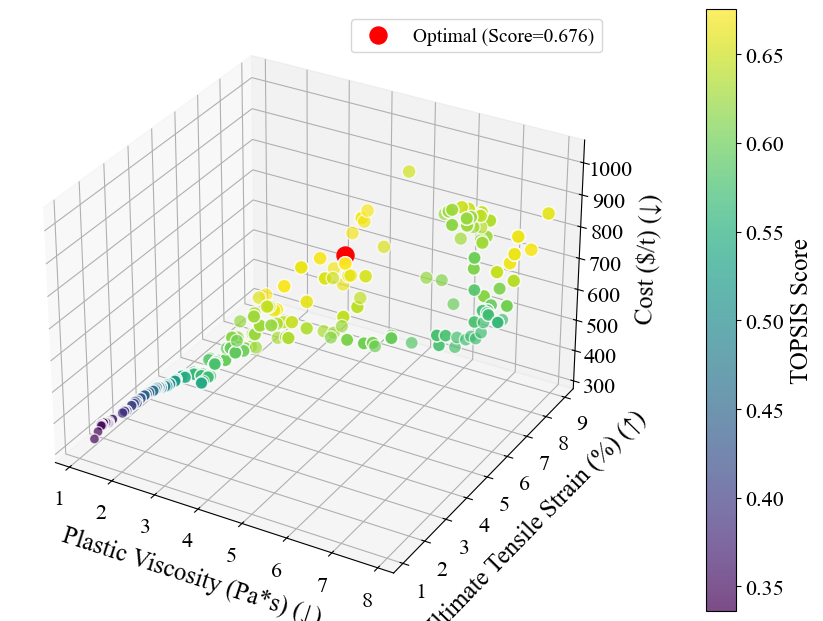

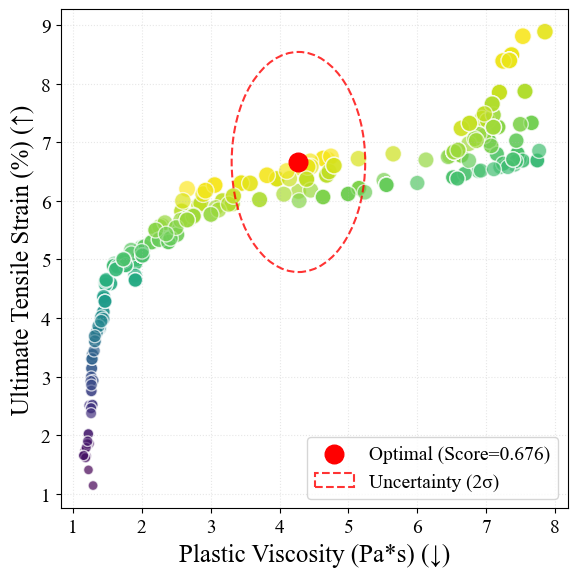

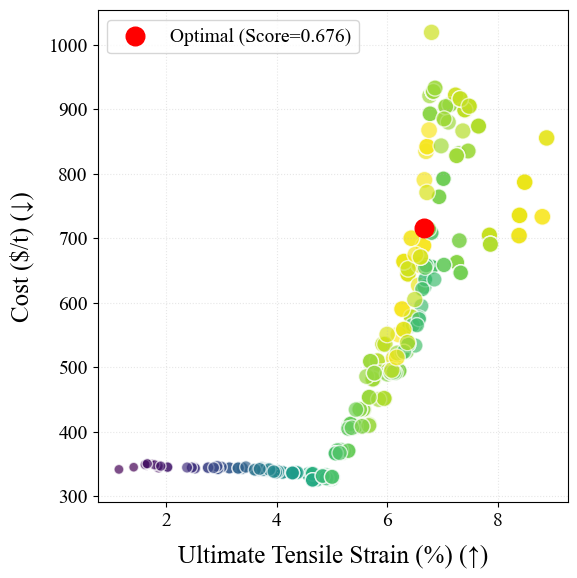

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches

# ---------------------- 核心计算函数（简化版） ----------------------
def dynamic_weight_adjustment(base_weights, p_v_std, us2_std, alpha=0.1):
    """线性比例法权重微调"""
    ratio = (p_v_std + 1e-6) / (us2_std + 1e-6)  # 避免除零
    delta = alpha * (ratio - 1)  # 当ratio=1时不调整
    
    # 应用调整（保护下限0.05）
    w_p_v = max(base_weights['p_v'] - delta, 0.05)
    w_us2 = max(base_weights['us2'] + delta, 0.05)
    w_cost = base_weights['cost']  # 成本权重不变
    
    # 归一化
    total = w_p_v + w_us2 + w_cost
    return {
        'p_v': w_p_v / total,
        'us2': w_us2 / total,
        'cost': w_cost / total
    }
def calculate_all_weights(trials, base_weights=None, alpha=0.1):
    """计算所有解的权重（简化版）"""
    if base_weights is None:
        base_weights = {'p_v': 0.3, 'us2': 0.6, 'cost': 0.1}
    
    p_v_std = np.array([t.user_attrs.get('p_v_std', 0) for t in trials])
    us2_std = np.array([t.user_attrs.get('us2_std', 0) for t in trials])
    
    weights_matrix = []
    for pv_std, us2_std in zip(p_v_std, us2_std):
        weights = dynamic_weight_adjustment(base_weights, pv_std, us2_std, alpha)
        weights_matrix.append([weights['p_v'], weights['us2'], weights['cost']])
    
    return np.array(weights_matrix), np.column_stack([
        [t.values[0] for t in trials],
        [t.values[1] for t in trials],
        [t.values[2] for t in trials]
    ])
# ---------------------- TOPSIS计算（保持不变） --------------------

def topsis_selection(F, weights=None):
    """支持逐点权重的TOPSIS计算"""
    norm_F = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0))
    norm_F[:, [0, 2]] = 1 - norm_F[:, [0, 2]]  # 处理最小化目标
    
    weighted = norm_F * weights if weights is not None else norm_F
    ideal = weighted.max(axis=0)
    nadir = weighted.min(axis=0)
    
    d_pos = np.sqrt(((weighted - ideal)**2).sum(axis=1))
    d_neg = np.sqrt(((weighted - nadir)**2).sum(axis=1))
    return d_neg / (d_pos + d_neg)

# ---------------------- 可视化函数 ----------------------
def plot_3d_pareto(trials, weights_matrix, topsis_scores):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'mathtext.fontset': 'stix',
        'font.size': 16
    })
    
    fig = plt.figure(figsize=(9, 6.5))
    ax = fig.add_subplot(111, projection='3d')
    
    # 提取数据
    p_v = np.array([t.values[0] for t in trials])
    us2 = np.array([t.values[1] for t in trials])
    cost = np.array([t.values[2] for t in trials])
    
    # 最优解处理
    best_idx = np.argmax(topsis_scores)
    mask = np.arange(len(trials)) != best_idx
    
    # 绘制普通点
    scatter = ax.scatter(
        p_v[mask], us2[mask], cost[mask],
        c=topsis_scores[mask],
        cmap='viridis',
        s=50 + 50*(topsis_scores[mask] - topsis_scores.min())/(topsis_scores.max() - topsis_scores.min()),
        alpha=0.7,
        edgecolors='w'
    )
    
    # 标记最优解
    ax.scatter(
        p_v[best_idx], us2[best_idx], cost[best_idx],
        c='red',
        s=100 + 50*(topsis_scores[best_idx] - topsis_scores.min())/(topsis_scores.max() - topsis_scores.min()),
        alpha=1.0,
        label=f'Optimal (Score={topsis_scores[best_idx]:.3f})'
    )
    
    # 坐标轴设置
    ax.set_xlabel("Plastic Viscosity (Pa*s) (↓)", labelpad=10, fontsize=18)
    ax.set_ylabel("Ultimate Tensile Strain (%) (↑)", labelpad=10, fontsize=18)
    ax.set_zlabel("Cost ($/t) (↓)", labelpad=10, fontsize=18)
    ax.legend(loc='upper right', fontsize=14)
    
    # 颜色条
    cbar = fig.colorbar(scatter, ax=ax, pad=0.11)
    cbar.set_label('TOPSIS Score', fontsize=18)
    cbar.ax.tick_params(labelsize=16)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PATH}/3d_pareto.svg", bbox_inches='tight', dpi=600)
    plt.show()

def plot_2d_viscosity_strain(trials, topsis_scores):
    plt.rcParams.update({
        'font.family': 'Times New Roman', 
        'mathtext.fontset': 'stix',
        'font.size': 14
    })
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 提取数据
    p_v = np.array([t.values[0] for t in trials])
    p_v_std = np.array([t.user_attrs.get('p_v_std', 0) for t in trials])
    us2 = np.array([t.values[1] for t in trials])
    us2_std = np.array([t.user_attrs.get('us2_std', 0) for t in trials])
    
    # 归一化分数用于可视化
    norm_scores = (topsis_scores - topsis_scores.min()) / (topsis_scores.max() - topsis_scores.min())
    sizes = 50 + 100 * norm_scores
    
    # 绘制所有点
    scatter = ax.scatter(
        p_v, us2,
        c=norm_scores,
        cmap='viridis',
        s=sizes,
        alpha=0.7,
        edgecolors='w'
    )
    
    # 标记最优解
    best_idx = np.argmax(topsis_scores)
    ax.scatter(
        p_v[best_idx], us2[best_idx],
        c='red',
        s=sizes[best_idx]*1.2,
        alpha=1.0,
        label=f'Optimal (Score={topsis_scores[best_idx]:.3f})'
    )
    
    # 添加不确定性椭圆
    ellipse = patches.Ellipse(
        (p_v[best_idx], us2[best_idx]),
        width=2*p_v_std[best_idx],
        height=2*us2_std[best_idx],
        angle=0,
        edgecolor='red',
        facecolor='none',
        linestyle='--',
        linewidth=1.5,
        alpha=0.8,
        label='Uncertainty (2σ)'
    )
    ax.add_patch(ellipse)
    
    ax.set_xlabel("Plastic Viscosity (Pa*s) (↓)", labelpad=5, fontsize=18)
    ax.set_ylabel("Ultimate Tensile Strain (%) (↑)", labelpad=5, fontsize=18)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.legend(loc='lower right', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PATH}/2d_viscosity_strain.svg", bbox_inches='tight', dpi=600)
    plt.show()

def plot_2d_strain_cost(trials, topsis_scores):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'mathtext.fontset': 'stix',
        'font.size': 14
    })
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 提取数据
    us2 = np.array([t.values[1] for t in trials])
    cost = np.array([t.values[2] for t in trials])
    
    # 分数归一化用于可视化
    norm_scores = (topsis_scores - topsis_scores.min()) / (topsis_scores.max() - topsis_scores.min())
    sizes = 50 + 100 * norm_scores
    
    # 绘制所有点
    scatter = ax.scatter(
        us2, cost,
        c=norm_scores,
        cmap='viridis',
        s=sizes,
        alpha=0.7,
        edgecolors='w'
    )
    
    # 标记最优解
    best_idx = np.argmax(topsis_scores)
    ax.scatter(
        us2[best_idx], cost[best_idx],
        c='red',
        s=sizes[best_idx]*1.2,
        alpha=1.0,
        label=f'Optimal (Score={topsis_scores[best_idx]:.3f})'
    )
    
    ax.set_xlabel("Ultimate Tensile Strain (%) (↑)", labelpad=10, fontsize=18)
    ax.set_ylabel("Cost ($/t) (↓)", labelpad=10, fontsize=18)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.legend(loc='upper left', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_PATH}/2d_strain_cost.svg", bbox_inches='tight', dpi=600)
    plt.show()


# ---------------------- 主流程 ----------------------
def analyze_results(study, alpha=0.1, base_weights=None):
    """完整结果分析（包含最优解参数输出）"""
    if base_weights is None:
        base_weights = {'p_v': 0.2, 'us2': 0.6, 'cost': 0.1}
        
    trials = [t for t in study.best_trials if t.values[1] > 0]
    
    # 计算权重和得分
    weights_matrix, F = calculate_all_weights(trials, base_weights=base_weights, alpha=alpha)
    topsis_scores = topsis_selection(F, weights_matrix)
    
    # 构建结果DataFrame
    results = []
    for i, trial in enumerate(trials):
        results.append({
            **{k: trial.params[k] for k in VAR_NAMES},  # 所有输入参数
            'p_v': trial.values[0],
            'p_v_std': trial.user_attrs.get('p_v_std', np.nan),
            'us2': trial.values[1],
            'us2_std': trial.user_attrs.get('us2_std', np.nan),
            'Cost': trial.values[2],
            'Weight_p_v': weights_matrix[i, 0],
            'Weight_us2': weights_matrix[i, 1],
            'Weight_cost': weights_matrix[i, 2],
            'TOPSIS_Score': topsis_scores[i],
            'Uncertainty_Ratio': (trial.user_attrs.get('p_v_std', 0)+1e-6) / 
                                (trial.user_attrs.get('us2_std', 0)+1e-6)
        })
    
    results_df = pd.DataFrame(results)
    
    # 保存完整结果
    results_df.to_csv(f"{OUTPUT_PATH}/optuna_results.csv", index=False)
    
    # 提取最优解
    best_idx = np.argmax(topsis_scores)
    best_solution = results_df.iloc[best_idx].to_dict()
    
    # --- 打印最优解详细信息 ---
    print("\n" + "="*50)
    print(" BEST COMPROMISE SOLUTION ".center(50, '='))
    print("="*50)
    
    # 1. 目标函数值
    print("\n[Objective Values]")
    print(f"- Plastic Viscosity (Pa*s): {best_solution['p_v']:.3f} (std={best_solution['p_v_std']:.3f})")
    print(f"- Ultimate Tensile Strain (%): {best_solution['us2']:.3f} (std={best_solution['us2_std']:.3f})")
    print(f"- Cost ($/t): {best_solution['Cost']:.2f}")
    print(f"- TOPSIS Score: {best_solution['TOPSIS_Score']:.3f}")
    
    # 2. 动态权重信息
    print("\n[Weight Adjustment]")
    print(f"- Uncertainty Ratio (p_v_std/us2_std): {best_solution['Uncertainty_Ratio']:.2f}")
    print(f"- p_v Weight: {best_solution['Weight_p_v']:.3f} (base={base_weights['p_v']})")
    print(f"- us2 Weight: {best_solution['Weight_us2']:.3f} (base={base_weights['us2']})")
    
    # 3. 输入变量值（关键参数）
    print("\n[Input Parameters]")
    param_values = {k: best_solution[k] for k in VAR_NAMES}
    for param, value in param_values.items():
        print(f"- {param}: {value}")
    
    # 单独保存最优解
    best_df = pd.DataFrame([best_solution])
    best_df.to_csv(f"{OUTPUT_PATH}/best_solution.csv", index=False)
    
    print("\n" + "="*50)
    print(f" Results saved to {OUTPUT_PATH} ".center(50, '='))
    print("="*50)
    
    return trials, weights_matrix, topsis_scores

# 执行分析（可通过beta控制调整强度）
base_weights = {'p_v': 0.25, 'us2': 0.7, 'cost': 0.1}
trials, weights_matrix, topsis_scores = analyze_results(
    study, 
    alpha=0.1,  # 调整强度（建议0.05~0.2）
    base_weights=base_weights
)
# 可视化（保持不变）
plot_3d_pareto(trials, weights_matrix, topsis_scores)
plot_2d_viscosity_strain(trials, topsis_scores)
plot_2d_strain_cost(trials, topsis_scores)



=== 聚类中心特征 ===
      Viscosity       Strain          Cost         TOPSIS_Score Weight_p_v  \
           mean   std   mean   std    mean     std         mean       mean   
Label                                                                        
A          1.69  0.43   4.12  1.29  356.81   29.33         0.51       0.30   
B          7.02  0.65   7.33  0.63  778.06  108.32         0.63       0.28   
C          4.19  1.20   6.18  0.27  540.40   70.19         0.63       0.30   

      Weight_us2  
            mean  
Label             
A           0.60  
B           0.62  
C           0.61  

=== TOPSIS最佳解 ===
- Cluster: C
- Viscosity: 4.274
- Strain: 6.663
- Cost: 715.375
- TOPSIS Score: 0.676
- Dynamic Weights - p_v: 0.284, us2: 0.621


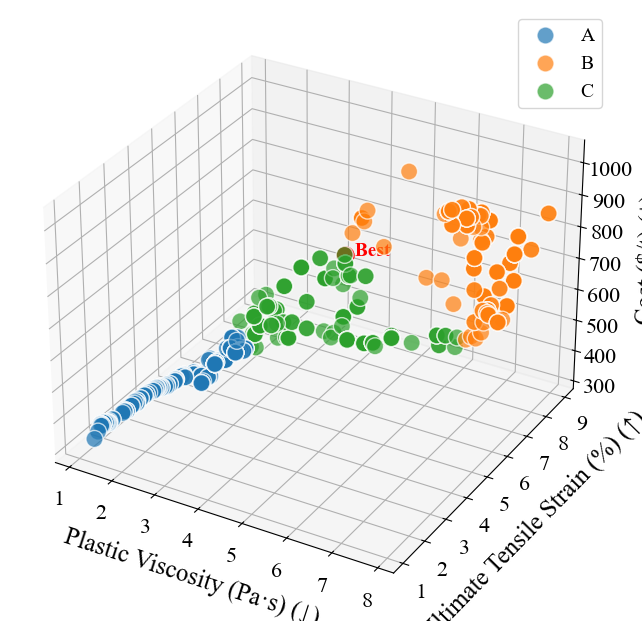

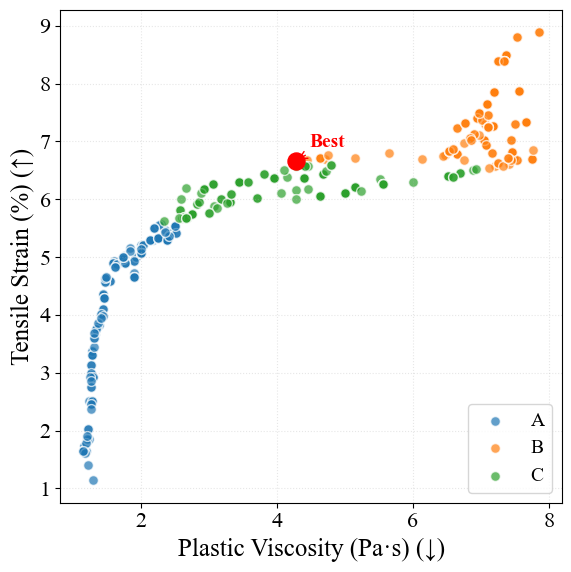

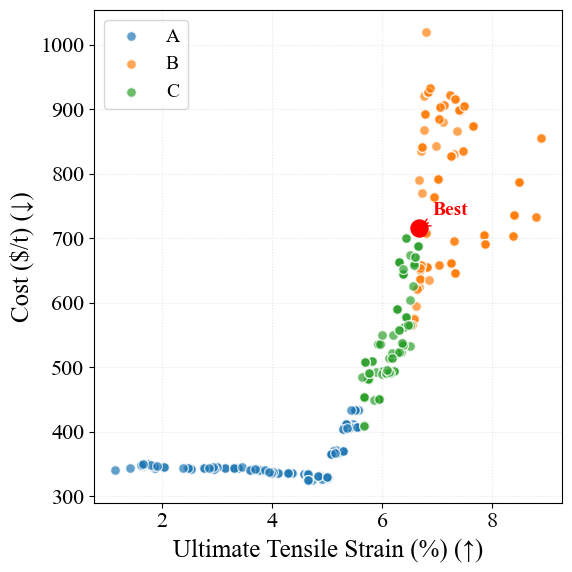

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def cluster_pareto_solutions(pareto_front):
    """对帕累托解进行K-means聚类分析"""
    F = np.array([[t.values[0], t.values[1], t.values[2]] for t in pareto_front])
    scaler = StandardScaler()
    F_scaled = scaler.fit_transform(F)
    
    kmeans = KMeans(n_clusters=3, random_state=SEED)
    clusters = kmeans.fit_predict(F_scaled)
    cluster_labels = {0:"A", 1:"B", 2:"C"}
    
    return F, clusters, cluster_labels

def plot_3d_pareto_with_clusters(pareto_front, weights_matrix=None, base_weights=None, alpha=0.1):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'mathtext.fontset': 'stix',
        'font.size': 16
    })
    
    F, clusters, cluster_labels = cluster_pareto_solutions(pareto_front)
    
    # 计算动态权重和TOPSIS分数
    if weights_matrix is None:
        weights_matrix, _ = calculate_all_weights(pareto_front, base_weights, alpha)
    topsis_scores = topsis_selection(F, weights_matrix)
    best_idx = np.argmax(topsis_scores)
    
    fig = plt.figure(figsize=(9, 6.5))
    ax = fig.add_subplot(111, projection='3d')
    
    colors = plt.cm.tab10.colors[:4]
    
    for i in range(3):
        mask = (clusters == i)
        ax.scatter(
            F[mask, 0], F[mask, 1], F[mask, 2],
            s=100 + 50*(topsis_scores[best_idx] - topsis_scores.min())/(topsis_scores.max() - topsis_scores.min()),
            color=colors[i],
            alpha=0.7,
            edgecolors='w',
            label=cluster_labels[i]
        )
    
    best_idx = np.argmax(topsis_scores)
    ax.scatter(
        F[best_idx, 0], F[best_idx, 1], F[best_idx, 2],
        c='red',
        s=100 + 50*(topsis_scores[best_idx] - topsis_scores.min())/(topsis_scores.max() - topsis_scores.min()),
        alpha=1.0
    )
    
    ax.text(
        F[best_idx, 0], F[best_idx, 1], F[best_idx, 2], 
        "  Best", 
        color='red',
        fontsize=14,
        weight='bold'
    )
    
    ax.set_xlabel("Plastic Viscosity (Pa·s) (↓)", labelpad=10, fontsize=18)
    ax.set_ylabel("Ultimate Tensile Strain (%) (↑)", labelpad=10, fontsize=18)
    ax.set_zlabel("Cost ($/t) (↓)", labelpad=10, fontsize=18)
    ax.legend(loc='upper right', fontsize=14)
    
    plt.tight_layout()
    plt.savefig("3d_pareto_clusters.svg", bbox_inches='tight', dpi=600)
    plt.show()

def plot_2d_viscosity_strain(pareto_front, weights_matrix=None, base_weights=None, alpha=0.1):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'mathtext.fontset': 'stix',
        'font.size': 16
    })
    
    F, clusters, cluster_labels = cluster_pareto_solutions(pareto_front)
    
    if weights_matrix is None:
        weights_matrix, _ = calculate_all_weights(pareto_front, base_weights, alpha)
    topsis_scores = topsis_selection(F, weights_matrix)
    best_idx = np.argmax(topsis_scores)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.tab10.colors[:4]
    
    for i in range(3):
        mask = (clusters == i)
        ax.scatter(
            F[mask, 0], F[mask, 1],
            s=50,
            color=colors[i],
            alpha=0.7,
            edgecolors='w',
            label=cluster_labels[i]
        )
    
    best_idx = np.argmax(topsis_scores)
    ax.scatter(
        F[best_idx, 0], F[best_idx, 1],
        c='red',
        s=100 + 50*(topsis_scores[best_idx] - topsis_scores.min())/(topsis_scores.max() - topsis_scores.min()),
        alpha=1.0,
    )
    
    ax.annotate(
        "Best", 
        xy=(F[best_idx, 0], F[best_idx, 1]),
        xytext=(10, 10),
        textcoords='offset points',
        color='red',
        fontsize=14,
        weight='bold',
        arrowprops=dict(arrowstyle="->", color='red')
    )
    
    ax.set_xlabel("Plastic Viscosity (Pa·s) (↓)", fontsize=18)
    ax.set_ylabel("Tensile Strain (%) (↑)", fontsize=18)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.legend(loc='lower right', fontsize=14)
    
    plt.tight_layout()
    plt.savefig("2d_viscosity_strain.svg", bbox_inches='tight', dpi=600)
    plt.show()

def plot_2d_strain_cost(pareto_front, weights_matrix=None, base_weights=None, alpha=0.1):
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'mathtext.fontset': 'stix',
        'font.size': 16
    })
    
    F, clusters, cluster_labels = cluster_pareto_solutions(pareto_front)
    
    if weights_matrix is None:
        weights_matrix, _ = calculate_all_weights(pareto_front, base_weights, alpha)
    topsis_scores = topsis_selection(F, weights_matrix)
    best_idx = np.argmax(topsis_scores)

    fig, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.tab10.colors[:4]
    
    for i in range(3):
        mask = (clusters == i)
        ax.scatter(
            F[mask, 1], F[mask, 2],
            s=50,
            color=colors[i],
            alpha=0.7,
            edgecolors='w',
            label=cluster_labels[i]
        )
    
    best_idx = np.argmax(topsis_scores)
    ax.scatter(
        F[best_idx, 1], F[best_idx, 2],
        c='red',
        s=100 + 50*(topsis_scores[best_idx] - topsis_scores.min())/(topsis_scores.max() - topsis_scores.min()),
        alpha=1.0
    )

    ax.annotate(
        "Best", 
        xy=(F[best_idx, 1], F[best_idx, 2]),
        xytext=(10, 10),
        textcoords='offset points',
        color='red',
        fontsize=14,
        weight='bold',
        arrowprops=dict(arrowstyle="->", color='red')
    )
    
    ax.set_xlabel("Ultimate Tensile Strain (%) (↑)", fontsize=18)
    ax.set_ylabel("Cost ($/t) (↓)", fontsize=18)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.legend(loc='upper left', fontsize=14)
    
    plt.tight_layout()
    plt.savefig("2d_strain_cost.svg", bbox_inches='tight', dpi=600)
    plt.show()

def analyze_clustered_solutions(study, base_weights=None, alpha=0.1):
    """完整聚类分析流程"""
    pareto_front = study.best_trials  
    if len(pareto_front) < 4:
        print("帕累托解数量不足(需要至少4个)，无法进行聚类分析")
        return None

    if base_weights is None:
        base_weights = {'p_v': 0.3, 'us2': 0.6, 'cost': 0.1}
    
    # 计算动态权重
    weights_matrix, F = calculate_all_weights(pareto_front, base_weights, alpha)
    
    # 计算TOPSIS分数
    topsis_scores = topsis_selection(F, weights_matrix)
    
    # 执行聚类
    F, clusters, cluster_labels = cluster_pareto_solutions(pareto_front)
    
    # 构建结果DataFrame
    cluster_results = pd.DataFrame({
        'Cluster': clusters,
        'Viscosity': F[:, 0],
        'Strain': F[:, 1],
        'Cost': F[:, 2],
        'Label': [cluster_labels[c] for c in clusters],
        'TOPSIS_Score': topsis_scores,
        'Weight_p_v': weights_matrix[:, 0],
        'Weight_us2': weights_matrix[:, 1]
    })
    
    print("\n=== 聚类中心特征 ===")
    cluster_stats = cluster_results.groupby('Label').agg({
        'Viscosity': ['mean', 'std'],
        'Strain': ['mean', 'std'],
        'Cost': ['mean', 'std'],
        'TOPSIS_Score': 'mean',
        'Weight_p_v': 'mean',
        'Weight_us2': 'mean'
    }).round(2)
    print(cluster_stats)
    
    print("\n=== TOPSIS最佳解 ===")
    best_idx = np.argmax(topsis_scores)
    best_solution = cluster_results.iloc[best_idx]
    print(f"- Cluster: {best_solution['Label']}")
    print(f"- Viscosity: {best_solution['Viscosity']:.3f}")
    print(f"- Strain: {best_solution['Strain']:.3f}")
    print(f"- Cost: {best_solution['Cost']:.3f}")
    print(f"- TOPSIS Score: {best_solution['TOPSIS_Score']:.3f}")
    print(f"- Dynamic Weights - p_v: {best_solution['Weight_p_v']:.3f}, us2: {best_solution['Weight_us2']:.3f}")
    
    # 绘制各视角图表
    plot_3d_pareto_with_clusters(pareto_front, weights_matrix, base_weights, alpha)
    plot_2d_viscosity_strain(pareto_front, weights_matrix, base_weights, alpha)
    plot_2d_strain_cost(pareto_front, weights_matrix, base_weights, alpha)
    
    return cluster_results

# 调用示例
base_weights = {'p_v': 0.25, 'us2': 0.7, 'cost': 0.1}
cluster_data = analyze_clustered_solutions(study, base_weights=base_weights, alpha=0.1)
